In [1]:
from astropy.io import fits
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
for file in os.listdir():
    if file.endswith(".fits"):
        header = fits.getheader(file)
        print(file, header.get("IMAGETYP"), header.get("FILTER"))

d007.fits None None
a205.fits None None
a086.fits None None
a069.fits None None
a194.fits None None
a244.fits None None
a028.fits None None
a213.fits None None
d011.fits None None
a090.fits None None
a004.fits None None
a053.fits None None
a116.fits None None
a045.fits None None
a100.fits None None
a012.fits None None
a157.fits None None
a120.fits None None
a065.fits None None
a209.fits None None
a177.fits None None
a198.fits None None
a032.fits None None
a161.fits None None
a024.fits None None
a085otzf.fits science V
a136.fits None None
a073.fits None None
a008.fits None None
a049.fits None None
a048.fits None None
a009.fits None None
a137.fits None None
a072.fits None None
a160.fits None None
a025.fits None None
a176.fits None None
a199.fits None None
a033.fits None None
a208.fits None None
a121.fits None None
a064.fits None None
a013.fits None None
a156.fits None None
a044.fits None None
a101.fits None None
a052.fits None None
a117.fits None None
a005.fits None None
a091.fits None N

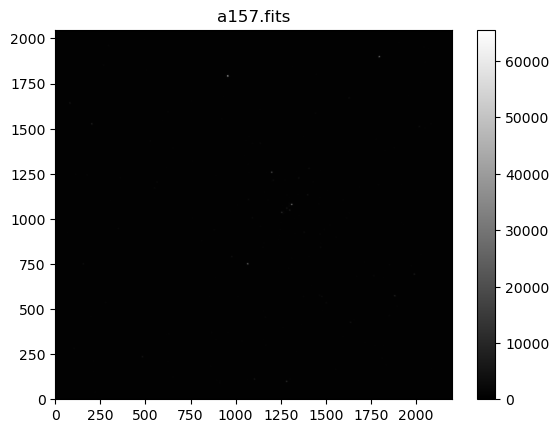

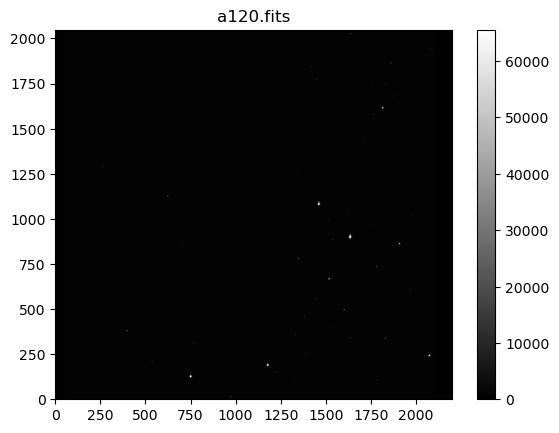

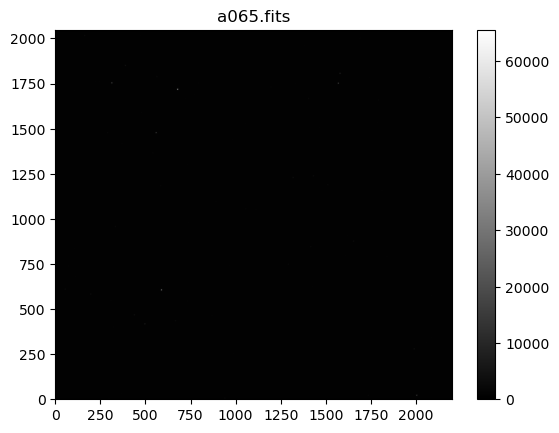

In [3]:
files = ["a157.fits", "a120.fits", "a065.fits"]

for f in files:
    data = fits.getdata(f)
    
    plt.imshow(data, cmap='gray', origin='lower')
    plt.colorbar()
    plt.title(f)
    plt.show()

In [4]:
for f in os.listdir():
    if f.endswith(".fits"):
        data = fits.getdata(f)
        mean_val = np.mean(data)
        print(f, mean_val)
    

d007.fits 659.1648990145596
a205.fits 748.4443956409801
a086.fits 730.9997487571022
a069.fits 676.5539992453836
a194.fits 697.5821355646307
a244.fits 803.4128819691051
a028.fits 25899.194220747515
a213.fits 1023.0635018643466
d011.fits 656.0819839754971
a090.fits 1033.6941643732243
a004.fits 61100.45396439986
a053.fits 17096.769208984377
a116.fits 1332.9488809481534
a045.fits 26772.30071644176
a100.fits 665.5508478338069
a012.fits 41632.715412819605
a157.fits 675.1623308771307
a120.fits 799.1845270330256
a065.fits 676.0828850763494
a209.fits 772.1645476740057
a177.fits 854.5241166548295
a198.fits 698.223290793679
a032.fits 26446.598512295808
a161.fits 726.6688880504262
a024.fits 38866.657142001066
a085otzf.fits 137.9169381245816
a136.fits 760.8607543945312
a073.fits 676.6724254261363
a008.fits 28916.02940784801
a049.fits 24625.191572487573
a048.fits 28266.99952237216
a009.fits 27086.90990456321
a137.fits 760.9532894620029
a072.fits 677.613105912642
a160.fits 726.5879436700994
a025.fits

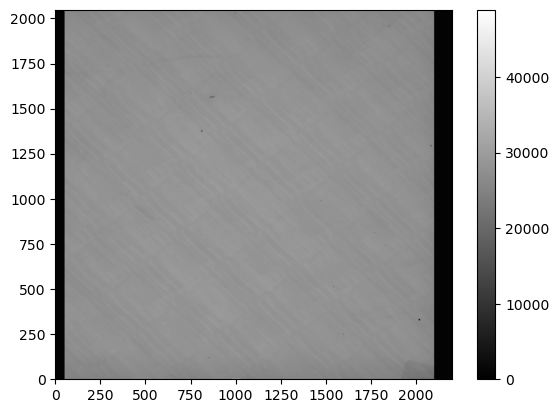

In [5]:
data = fits.getdata("a028.fits")

plt.imshow(data, cmap='gray', origin='lower')
plt.colorbar()
plt.show()

In [6]:
flat_files = []
flat_means = []

for f in os.listdir():
    if f.endswith(".fits") and not f.startswith("d"):
        data = fits.getdata(f)
        mean_val = np.mean(data)
        
        if mean_val > 15000:
            flat_files.append(f)
            flat_means.append(mean_val)

flat_files = sorted(flat_files)

print("Flat files:", flat_files)
print("Number of flats:", len(flat_files))

Flat files: ['a001.fits', 'a002.fits', 'a003.fits', 'a004.fits', 'a005.fits', 'a006.fits', 'a007.fits', 'a008.fits', 'a009.fits', 'a010.fits', 'a011.fits', 'a012.fits', 'a013.fits', 'a014.fits', 'a015.fits', 'a016.fits', 'a017.fits', 'a018.fits', 'a019.fits', 'a020.fits', 'a021.fits', 'a022.fits', 'a023.fits', 'a024.fits', 'a025.fits', 'a026.fits', 'a027.fits', 'a028.fits', 'a029.fits', 'a030.fits', 'a031.fits', 'a032.fits', 'a033.fits', 'a034.fits', 'a035.fits', 'a036.fits', 'a037.fits', 'a038.fits', 'a039.fits', 'a040.fits', 'a041.fits', 'a042.fits', 'a044.fits', 'a045.fits', 'a046.fits', 'a047.fits', 'a048.fits', 'a049.fits', 'a051.fits', 'a052.fits', 'a053.fits', 'a054.fits', 'a055.fits', 'a056.fits', 'a057.fits', 'a058.fits', 'a059.fits', 'a060.fits', 'a061.fits']
Number of flats: 59


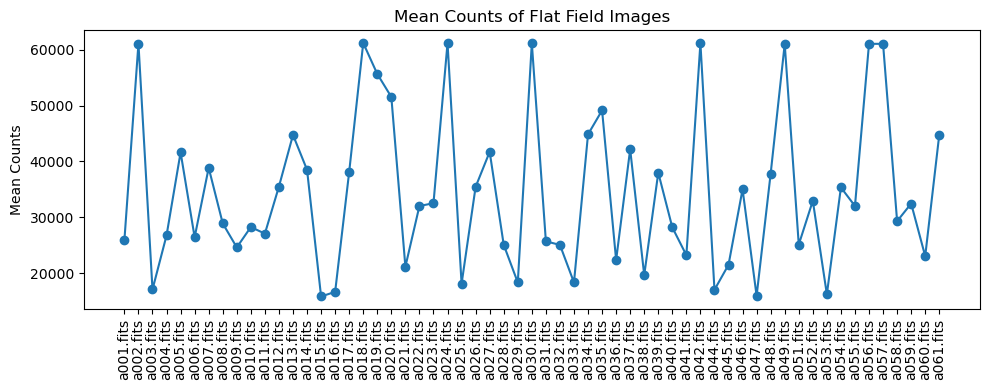

In [7]:
plt.figure(figsize=(10,4))
plt.plot(flat_files, flat_means, marker='o')
plt.xticks(rotation=90)
plt.ylabel("Mean Counts")
plt.title("Mean Counts of Flat Field Images")
plt.tight_layout()
plt.show()

In [10]:
scaled_flats = []

for f in flat_files:
    data = fits.getdata(f).astype(float)
    mean_val = np.mean(data)
    scaled = data / mean_val
    scaled_flats.append(scaled)

scaled_flats = np.array(scaled_flats)

In [11]:
print(scaled_flats.shape)

(59, 2048, 2200)


# Each flat was normalized by dividing by its mean value, which ensures that all images are on the same scale before combination

In [12]:
master_mean = np.mean(scaled_flats, axis=0)

In [13]:
master_median = np.median(scaled_flats, axis=0)

In [14]:
from astropy.stats import sigma_clip

clipped = sigma_clip(scaled_flats, sigma=3, axis=0)
master_clip = np.mean(clipped, axis=0)

In [20]:
from astropy.stats import sigma_clip

weights = np.array(flat_means)
weights = weights / np.sum(weights)

clipped = sigma_clip(scaled_flats, sigma=3, axis=0)
filled = clipped.filled(np.nan)

master_weighted = np.nansum(
    filled * weights[:, None, None], axis=0
) / np.nansum(
    (~np.isnan(filled)) * weights[:, None, None], axis=0
)

In [21]:
print(master_weighted.shape)

(2048, 2200)


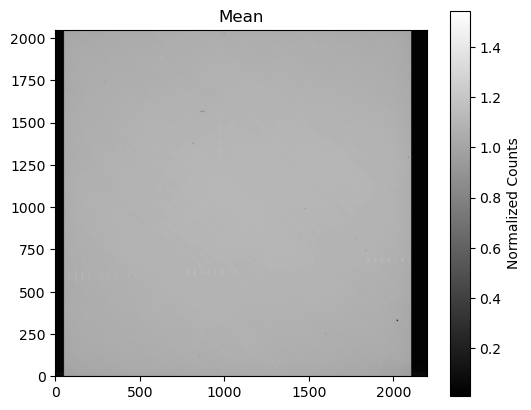

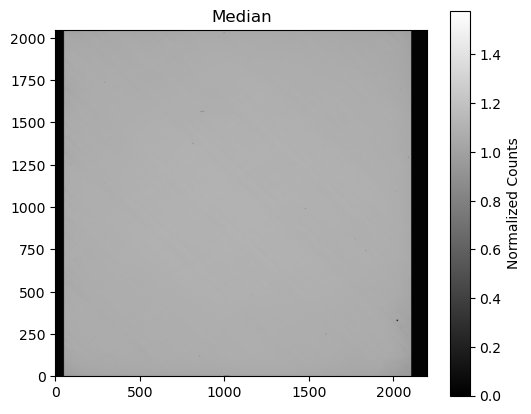

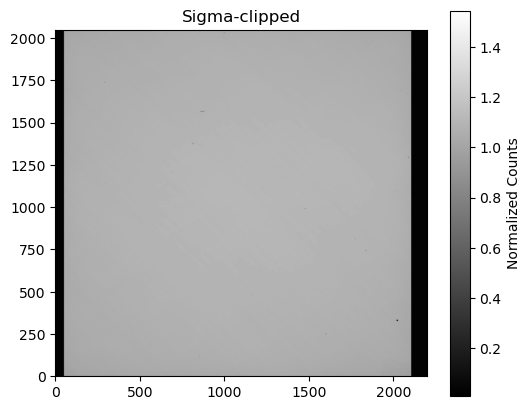

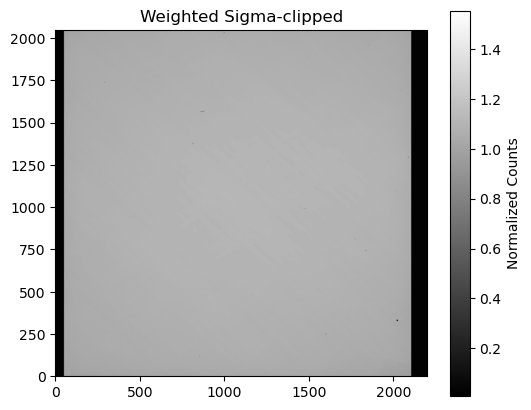

In [22]:
masters = {
    "Mean": master_mean,
    "Median": master_median,
    "Sigma-clipped": master_clip,
    "Weighted Sigma-clipped": master_weighted
}

for name, img in masters.items():
    plt.figure(figsize=(6,5))
    plt.imshow(img, cmap='gray', origin='lower')
    plt.colorbar(label='Normalized Counts')
    plt.title(name)
    plt.show()

In [23]:
for name, img in masters.items():
    rms = np.std(img)
    print(f"{name}: RMS = {rms:.6f}")

Mean: RMS = 0.266313
Median: RMS = 0.266725
Sigma-clipped: RMS = 0.266743
Weighted Sigma-clipped: RMS = 0.266810


# The RMS values are very similar for all methods, indicating that the data are relatively clean. The mean has the lowest RMS, but sigma-clipped methods are preferred because they are less affected by outliers without significantly increasing noise.

In [25]:
master_flat = master_weighted

In [26]:
mean_flat = np.mean(master_flat)
master_flat_norm = master_flat / mean_flat

In [27]:
print(np.mean(master_flat_norm))

0.9999999999999993


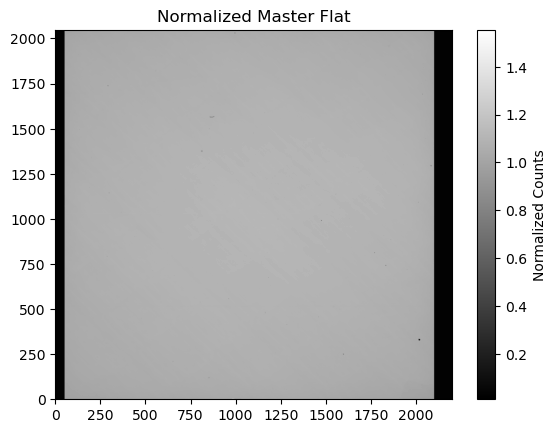

In [28]:
plt.imshow(master_flat_norm, cmap='gray', origin='lower')
plt.colorbar(label='Normalized Counts')
plt.title("Normalized Master Flat")
plt.show()

In [29]:
science_files = ["a085otzf.fits"]

In [36]:
corrected_images = [] #

for f in science_files:
    data = fits.getdata(f).astype(float)
    corrected = data / master_flat_norm
    corrected_images.append(corrected)

ValueError: operands could not be broadcast together with shapes (2048,2048) (2048,2200) 

In [31]:
print("science shape:", fits.getdata("a085otzf.fits").shape)
print("master flat shape:", master_flat_norm.shape)

science shape: (2048, 2048)
master flat shape: (2048, 2200)


In [32]:
master_flat_trimmed = master_flat_norm[:, :2048]
print(master_flat_trimmed.shape)

(2048, 2048)


In [34]:
corrected_images = []

for f in science_files:
    data = fits.getdata(f).astype(float)
    corrected = data / master_flat_trimmed
    corrected_images.append(corrected)
    corrected_images = []

for f in science_files:
    data = fits.getdata(f).astype(float)
    corrected = data / master_flat_trimmed
    corrected_images.append(corrected)

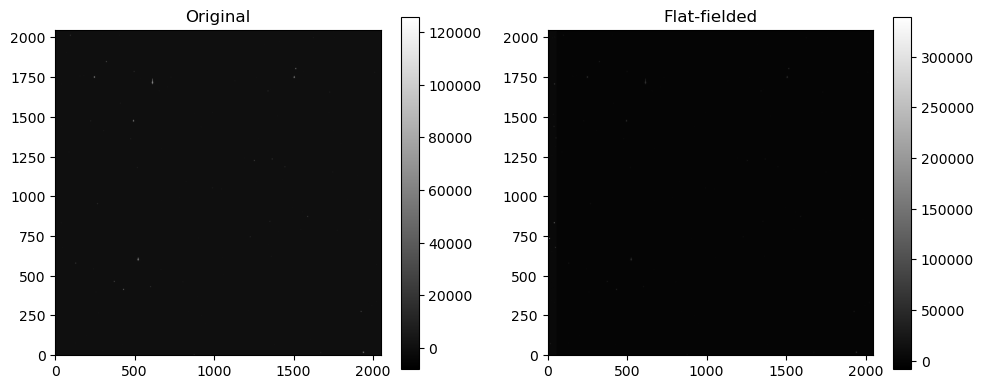

In [35]:
for i, f in enumerate(science_files):
    original = fits.getdata(f).astype(float)
    corrected = corrected_images[i]

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(original, cmap='gray', origin='lower')
    plt.colorbar()
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(corrected, cmap='gray', origin='lower')
    plt.colorbar()
    plt.title("Flat-fielded")

    plt.tight_layout()
    plt.show()

In [39]:
flat_files = []
bias_files = []

for f in os.listdir():
    if f.endswith(".fits"):
        data = fits.getdata(f)
        mean_val = np.mean(data)

        if mean_val > 20000:
            flat_files.append(f)
        elif mean_val < 2000:
            bias_files.append(f)

print("Flats:", flat_files[:5])
print("Bias:", bias_files[:5])

Flats: ['a028.fits', 'a004.fits', 'a045.fits', 'a012.fits', 'a032.fits']
Bias: ['d007.fits', 'a205.fits', 'a086.fits', 'a069.fits', 'a194.fits']


In [40]:
F1, F2 = flat_files[0], flat_files[1]
B1, B2 = bias_files[0], bias_files[1]

In [41]:
def load_trim(f):
    data = fits.getdata(f).astype(float)
    return data[:, :2048]

F1_data = load_trim(F1)
F2_data = load_trim(F2)
B1_data = load_trim(B1)
B2_data = load_trim(B2)

print(F1_data.shape, F2_data.shape, B1_data.shape, B2_data.shape)

(2048, 2048) (2048, 2048) (2048, 2048) (2048, 2048)


In [42]:
F1_ff = F1_data / master_flat_trimmed
F2_ff = F2_data / master_flat_trimmed

In [43]:
yslice = slice(500, 1500)
xslice = slice(500, 1500)

F1_reg = F1_ff[yslice, xslice]
F2_reg = F2_ff[yslice, xslice]
B1_reg = B1_data[yslice, xslice]
B2_reg = B2_data[yslice, xslice]

In [44]:
F1_mean = np.mean(F1_reg)
F2_mean = np.mean(F2_reg)
B1_mean = np.mean(B1_reg)
B2_mean = np.mean(B2_reg)

print("F1 mean:", F1_mean)
print("F2 mean:", F2_mean)
print("B1 mean:", B1_mean)
print("B2 mean:", B2_mean)

F1 mean: 25989.448902821532
F2 mean: 59658.28899266713
B1 mean: 661.595504
B2 mean: 755.208149


In [45]:
flat_diff = F1_reg - F2_reg
bias_diff = B1_reg - B2_reg

flat_var = np.var(flat_diff)
bias_var = np.var(bias_diff)

print("flat variance:", flat_var)
print("bias variance:", bias_var)

flat variance: 581338.9314409951
bias variance: 236885.11061310393


In [46]:
gain = ((F1_mean + F2_mean) - (B1_mean + B2_mean)) / (flat_var - bias_var)
print("Gain (e-/ADU):", gain)

Gain (e-/ADU): 0.24453476532802132


In [47]:
read_noise = gain * np.sqrt(bias_var / 2)
print("Read noise (e-):", read_noise)

Read noise (e-): 84.15782353723151


# A central region was used instead of the whole frame because the edges may contain overscan areas or artifacts that would introduce bias. Gain and read noise were found using two flat frames and two bias frames following the photon transfer method in Howell. The flats were corrected with a normalized master flat to remove sensitivity variations from pixel to pixel. 